In [11]:
%load_ext autoreload
%autoreload 2
import random
import pandas as pd 
from scipy.special import softmax 
import h5py
import pyBigWig

from kerasAC.helpers.transform_bpnet_io import * 
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,10
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## load the model labels & predictions 

In [12]:
#load the predictions from bpnet,tobias,and 6mer bias models 
preds_bpnet=h5py.File("../idr_preds/bpnet.bias.preds.k562.0.predictions",'r')
preds_tobias=h5py.File("../idr_preds/tobias.bias.preds.k562.0.predictions",'r')
preds_6mer=h5py.File("../idr_preds/6mer.bias.preds.k562.0.predictions",'r')


In [13]:
coords=preds_bpnet['coords'][:]
coords=[tuple([i.decode('utf8')  for i in j[0:2]]) for j in coords]
coord_to_index={}  
for i in range(len(coords)): 
    cur_chrom=coords[i][0] 
    cur_pos=int(coords[i][1])
    coord_to_index[tuple([cur_chrom,cur_pos])]=i


## q20 

In [14]:
index=0

In [15]:
bpnet=get_model_outputs_to_plot(preds_bpnet,[index])
tobias=get_model_outputs_to_plot(preds_tobias,[index])
sixmer=get_model_outputs_to_plot(preds_6mer,[index])
toplot=bpnet

chr1
144412667


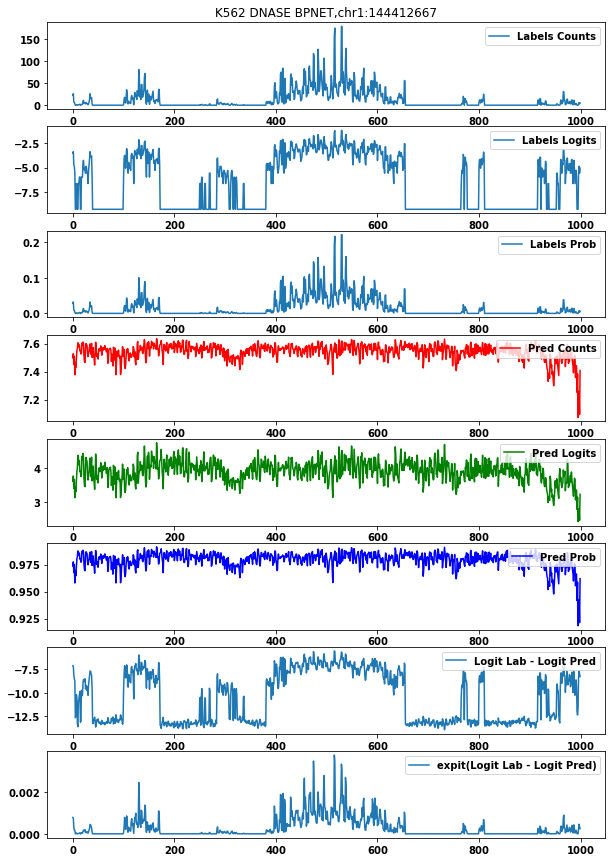

In [16]:
plt.rcParams["figure.figsize"]=10,15
for i in range(1): 
    (chrom,summit)=coords[i]
    print(chrom)
    print(summit)
    fig, axes = plt.subplots(8, 1)
    #labels 
    axes[0].plot(toplot['labels_counts'][i],label='Labels Counts')
    axes[1].plot(toplot['labels_logits'][i],label='Labels Logits')
    axes[2].plot(toplot['labels_prob'][i],label='Labels Prob')

    #predict counts 
    axes[3].plot(toplot['predictions_counts'][i],label='Pred Counts',color='r')
    axes[4].plot(toplot['predictions_logits'][i],label='Pred Logits',color='g')
    axes[5].plot(toplot['predictions_prob'][i],label='Pred Prob',color='b')

    #observed - predicted (logit space)
    axes[6].plot(toplot['delta_logits'][i],label='Logit Lab - Logit Pred')
    axes[7].plot(toplot['delta_prob'][i],label='expit(Logit Lab - Logit Pred)')
      
    axes[0].set_title('K562 DNASE BPNET,'+str(chrom)+":"+str(summit))
    axes[0].legend(loc=1)
    axes[1].legend(loc=1) 
    axes[2].legend(loc=1)
    axes[3].legend(loc=1)
    axes[4].legend(loc=1)
    axes[5].legend(loc=1)
    axes[6].legend(loc=1)
    axes[7].legend(loc=1)


In [17]:
bpnet=get_model_outputs_to_plot(preds_bpnet)
toplot=bpnet

chr1
778758


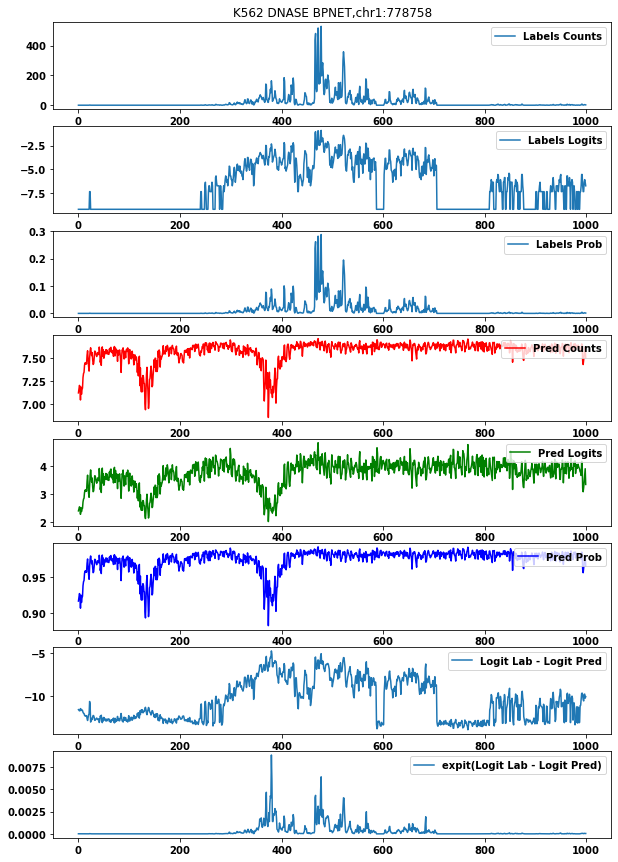

In [18]:
plt.rcParams["figure.figsize"]=10,15
for i in range(1,2): 
    (chrom,summit)=coords[i]
    print(chrom)
    print(summit)
    fig, axes = plt.subplots(8, 1)
    #labels 
    axes[0].plot(toplot['labels_counts'][i],label='Labels Counts')
    axes[1].plot(toplot['labels_logits'][i],label='Labels Logits')
    axes[2].plot(toplot['labels_prob'][i],label='Labels Prob')

    #predict counts 
    axes[3].plot(toplot['predictions_counts'][i],label='Pred Counts',color='r')
    axes[4].plot(toplot['predictions_logits'][i],label='Pred Logits',color='g')
    axes[5].plot(toplot['predictions_prob'][i],label='Pred Prob',color='b')

    #observed - predicted (logit space)
    axes[6].plot(toplot['delta_logits'][i],label='Logit Lab - Logit Pred')
    axes[7].plot(toplot['delta_prob'][i],label='expit(Logit Lab - Logit Pred)')
      
    axes[0].set_title('K562 DNASE BPNET,'+str(chrom)+":"+str(summit))
    axes[0].legend(loc=1)
    axes[1].legend(loc=1) 
    axes[2].legend(loc=1)
    axes[3].legend(loc=1)
    axes[4].legend(loc=1)
    axes[5].legend(loc=1)
    axes[6].legend(loc=1)
    axes[7].legend(loc=1)


In [19]:
from kerasAC.helpers.mnnll import * 

In [28]:
true_profs=np.expand_dims(np.expand_dims(toplot['labels_counts'],axis=1),axis=-1)
log_pred_profs=np.expand_dims(np.expand_dims(toplot['predictions_logits'],axis=1),axis=-1)
true_counts=np.expand_dims(np.expand_dims(toplot['labels_sum'],axis=1),axis=-1)
batch_size=100
multinomial_nll=profile_multinomial_nll(true_profs,
                       log_pred_profs,
                       true_counts)

In [30]:
multinomial_nll.shape

(154628, 1)